Simulating Scrambling for MFIM ...


Mapping MFIM: 100%|███████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 331.47it/s]


Simulating Scrambling for TFIM ...


Mapping TFIM: 100%|███████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 334.05it/s]


Simulating Scrambling for PXP ...


Mapping PXP: 100%|████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 357.08it/s]


Simulating Scrambling for MBL ...


Mapping MBL: 100%|████████████████████████████████████████████████████████████████████| 51/51 [00:00<00:00, 331.99it/s]


数据已保存到：E:\Quantum_Scar_Project\classical mutual information\数据集\scrambling_heatmaps_S_Q_I2.npz


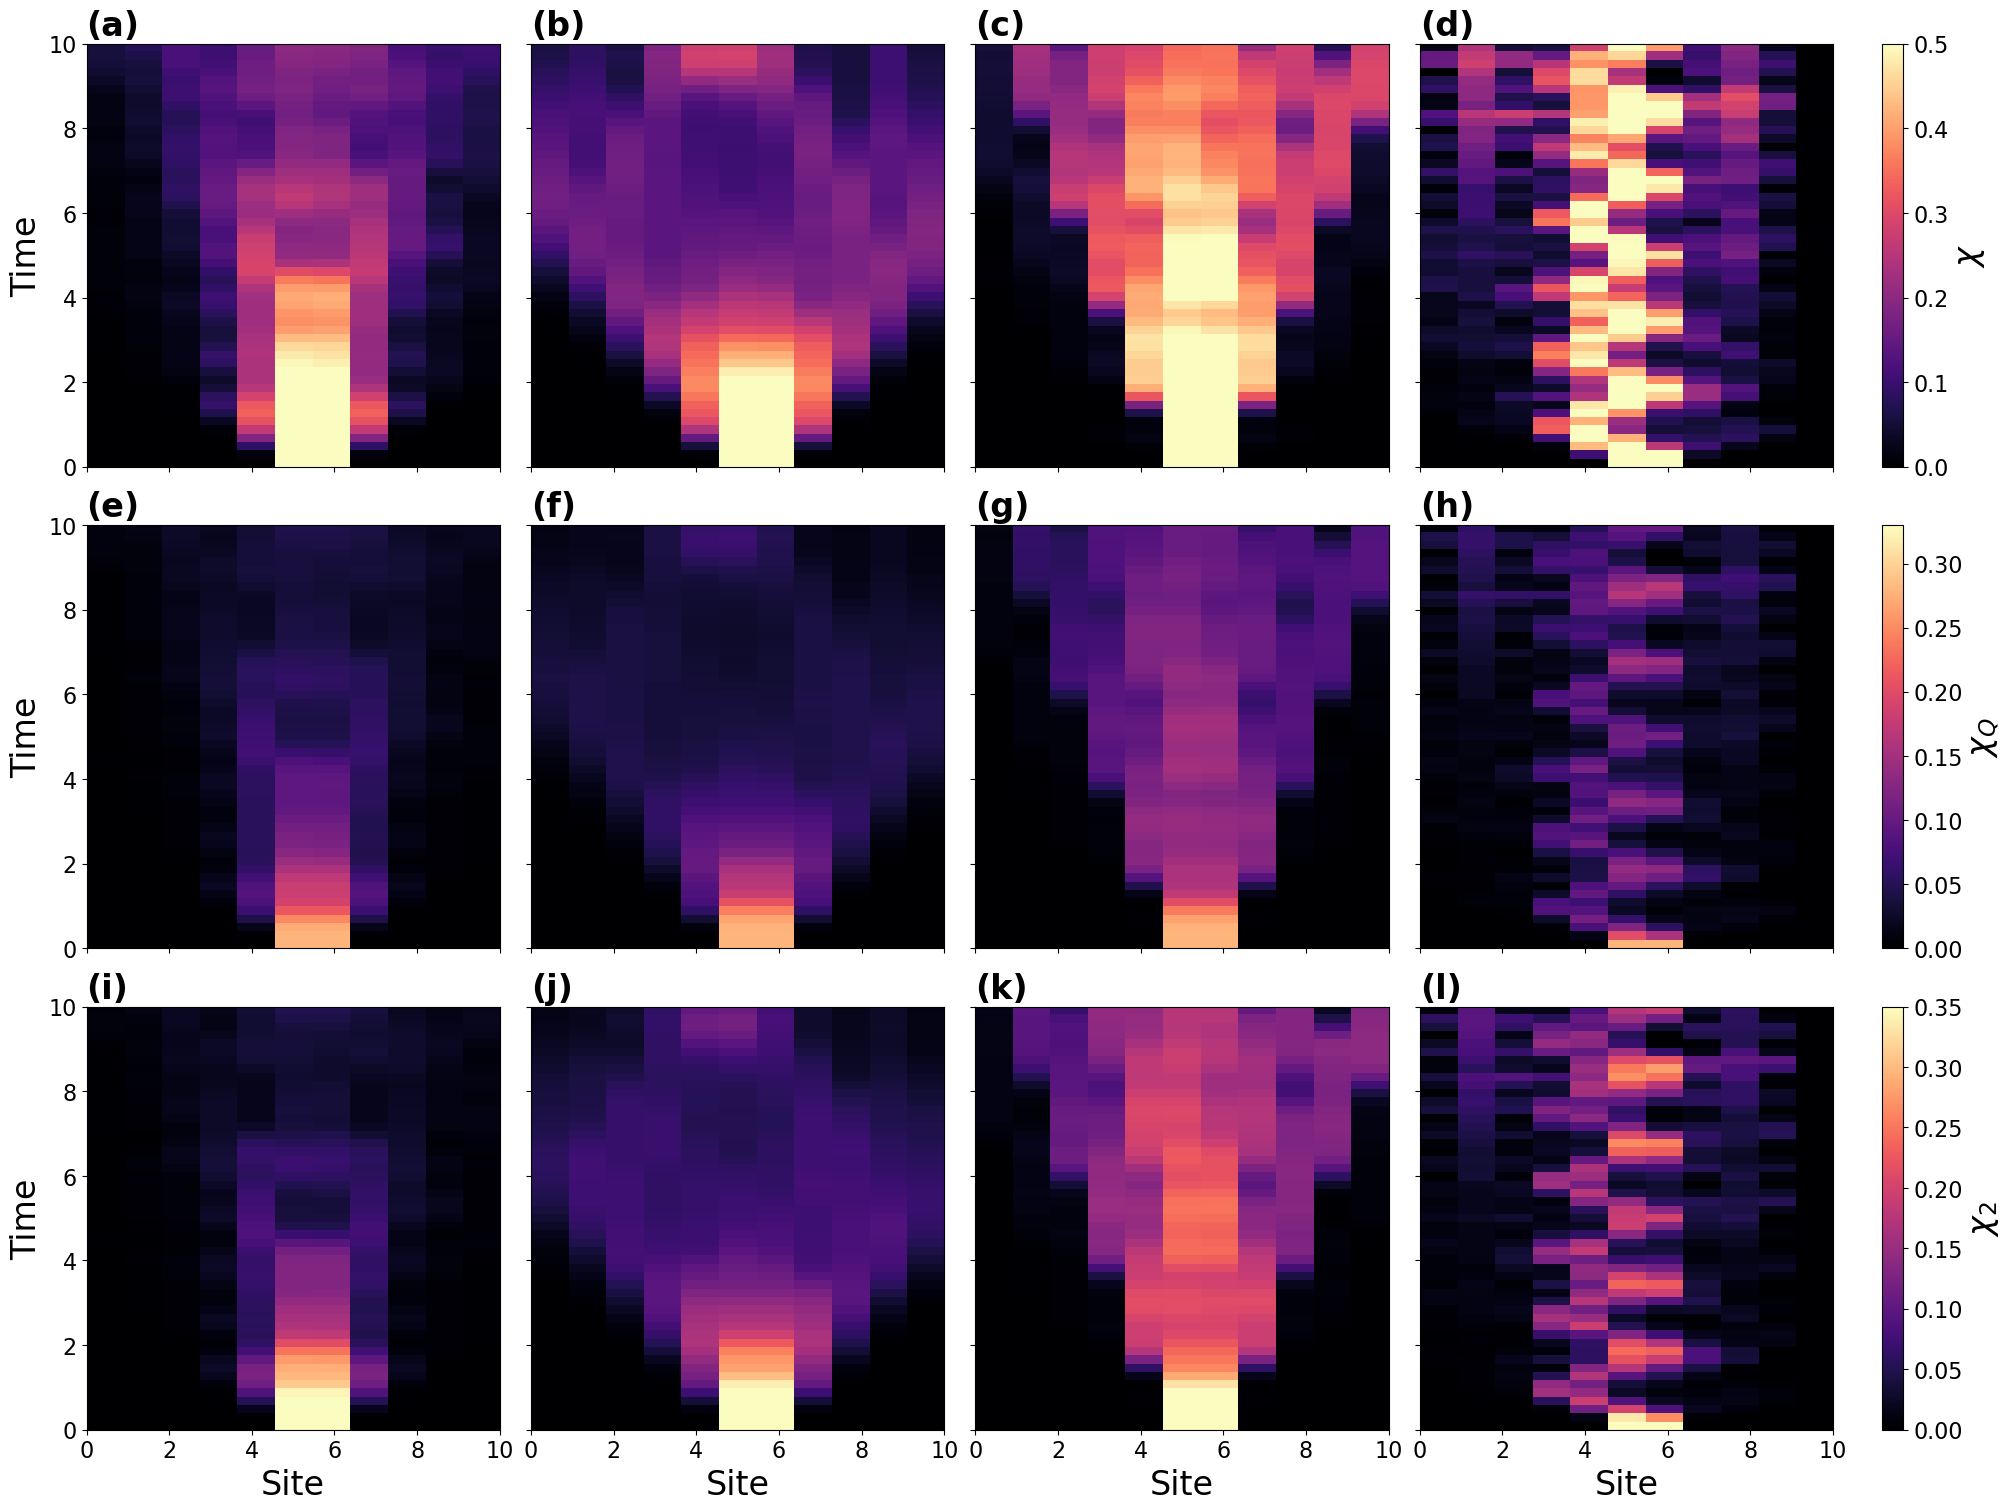

In [2]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import itertools
import os

warnings.filterwarnings("ignore")

# 1. 熵的定义与相关函数

def get_von_neumann_S(rho):
    """冯诺依曼熵 S = -Tr(rho log rho)"""
    evals = np.linalg.eigvalsh(rho)
    evals = evals[evals > 1e-15] 
    return -np.sum(evals * np.log2(evals))

def get_subentropy_Q(rho):
    """Subentropy Q"""
    evals = np.linalg.eigvalsh(rho)
    evals = np.clip(evals, 0, 1)
    if np.sum(evals) > 0:
        evals /= np.sum(evals)
    
    n = len(evals)
    Q = 0.0
    if n > 1:
        diffs = np.diff(evals)
        if np.any(np.abs(diffs) < 1e-9):
            evals += np.random.uniform(-1e-11, 1e-11, size=n)
            evals = np.sort(evals)
            evals /= np.sum(evals)

    for i in range(n):
        lam_i = evals[i]
        if lam_i < 1e-15: continue
        prod_term = 1.0
        for j in range(n):
            if i == j: continue
            lam_j = evals[j]
            denom = lam_i - lam_j
            if abs(denom) < 1e-15: denom = 1e-15 * np.sign(denom)
            prod_term *= lam_i / denom
        Q += -lam_i * np.log2(lam_i) * prod_term
    return max(0.0, Q)

def get_renyi2_subentropy_I2(rho):
    """
    Classical-Rényi-2 Subentropy (Q_2 指标)
    """
    purity = np.real(np.trace(rho @ rho))
    if purity > 1.0: purity = 1.0 
    val = np.log2(2.0 / (1.0 + purity))
    return val

def get_holevo_info(rho0, rho1, metric='I2'):
    """
    信息量，衡量 rho0 和 rho1 的可区分度。
    """
    rho_mix = 0.5 * (rho0 + rho1)
    
    if metric == 'S':
        func = get_von_neumann_S
    elif metric == 'Q':
        func = get_subentropy_Q
    else: # 默认使用 I2
        func = get_renyi2_subentropy_I2
        
    chi = func(rho_mix) - 0.5 * (func(rho0) + func(rho1))
    return max(0.0, chi)

def get_reduced_rho(psi_full, L, keep_sites):
    psi_tensor = psi_full.reshape([2] * L)
    all_indices = list(range(L))
    trace_indices =[i for i in all_indices if i not in keep_sites]
    
    perm = keep_sites + trace_indices
    psi_permuted = psi_tensor.transpose(perm)
    
    dim_A = 2 ** len(keep_sites)
    dim_B = 2 ** len(trace_indices)
    
    psi_matrix = psi_permuted.reshape((dim_A, dim_B))
    rho = psi_matrix @ psi_matrix.conj().T
    return rho

# 2. 系统构建类

class QuantumChain:
    def __init__(self, L, model_type, **kwargs):
        self.L = L; self.dim = 2**L; self.pxp_basis = None; self.pxp_map = None
        if model_type == 'MFIM':
            J=1.0; h=(np.sqrt(5)+1)/4; g=(np.sqrt(5)+5)/8
            self.H = self._build_mfim(J, g, h)
        elif model_type == 'TFIM':
            self.H = self._build_tfim(J=1.0, h=0.6)
        elif model_type == 'PXP':
            self.H, self.pxp_basis, self.pxp_map = self._build_pxp()
            self.dim_valid = len(self.pxp_basis)
        elif model_type == 'MBL':
            W = kwargs.get('W', 8.0)
            self.H = self._build_mbl_corrected(W)
            
    def _kron_list(self, matrices):
        res = matrices[0]
        for m in matrices[1:]: res = sp.kron(res, m)
        return res

    def _build_mfim(self, J, g, h):
        sx = sp.csr_matrix([[0,1],[1,0]]); sz = sp.csr_matrix([[1,0],[0,-1]]); id2 = sp.identity(2)
        H = sp.csr_matrix((self.dim, self.dim))
        for i in range(self.L): ops=[id2]*self.L; ops[i]=sx; H+=g*self._kron_list(ops)
        for i in range(1,self.L-1): ops=[id2]*self.L; ops[i]=sz; H+=h*self._kron_list(ops)
        for i in range(self.L-1): ops=[id2]*self.L; ops[i]=sz; ops[i+1]=sz; H+=J*self._kron_list(ops)
        return H

    def _build_tfim(self, J, h):
        sx = sp.csr_matrix([[0,1],[1,0]]); sz = sp.csr_matrix([[1,0],[0,-1]]); id2 = sp.identity(2)
        H = sp.csr_matrix((self.dim, self.dim), dtype=complex)
        for i in range(self.L):
            ops = [id2] * self.L
            ops[i] = sx
            H += (-h) * self._kron_list(ops)
        for i in range(self.L - 1):
            ops = [id2] * self.L
            ops[i] = sz
            ops[i+1] = sz
            H += (-J) * self._kron_list(ops)
        return H

    def _build_pxp(self):
        basis=[]; 
        for i in range(2**self.L):
            if (i&(i<<1))==0: basis.append(i)
        basis=np.array(basis, dtype=np.int32); dim_valid=len(basis)
        pxp_map={s:i for i,s in enumerate(basis)}
        rows,cols,data=[],[],[]
        for idx,state in enumerate(basis):
            for i in range(self.L):
                m_i=1<<(self.L-1-i); m_l=1<<(self.L-1-(i-1)) if i>0 else 0; m_r=1<<(self.L-1-(i+1)) if i<self.L-1 else 0
                if (state&m_l)==0 and (state&m_r)==0:
                    ns=state^m_i
                    if ns in pxp_map: rows.append(pxp_map[ns]); cols.append(idx); data.append(1.0)
        H=sp.csr_matrix((data,(rows,cols)), shape=(dim_valid, dim_valid))
        return H, basis, pxp_map

    def _build_mbl_corrected(self, W):
        sx = sp.csr_matrix([[0,1],[1,0]]); sy = sp.csr_matrix([[0,-1j],[1j,0]]); sz = sp.csr_matrix([[1,0],[0,-1]]); id2 = sp.identity(2)
        H = sp.csr_matrix((self.dim, self.dim), dtype=complex)
        np.random.seed(42); fields = np.random.uniform(-W, W, self.L)
        J_pauli = 1 
        for i in range(self.L-1):
            for op in [sx, sy, sz]: ops=[id2]*self.L; ops[i]=op; ops[i+1]=op; H+=J_pauli*self._kron_list(ops)
        for i in range(self.L): ops=[id2]*self.L; ops[i]=sz; H+=(fields[i])*self._kron_list(ops)
        return H

# 3. 运行逻辑：信息扩散热力图 (S, Q 和 Q_2)

def run_scrambling_heatmaps(L, times):
    sub_size = 2 
    models =['MFIM', 'TFIM', 'PXP', 'MBL']
    
    heatmap_results = {'S': {}, 'Q': {}, 'I2': {}}
    center_site = L // 2 
    
    neel_int = 0
    for i in range(0, L, 2): 
        neel_int |= (1 << (L - 1 - i))
    
    allzero_int = 0
    pert_allzero_int = allzero_int ^ (1 << (L - 1 - center_site))
        
    mask_center = 1 << (L - 1 - center_site)
    if (neel_int & mask_center) > 0:
        pert_int = neel_int ^ mask_center
    else:
        mask_left = 1 << (L - 1 - (center_site - 1))
        if (neel_int & mask_left) > 0:
            pert_int = neel_int ^ mask_left
        else:
            mask_right = 1 << (L - 1 - (center_site + 1))
            pert_int = neel_int ^ mask_right

    for m_name in models:
        print(f"Simulating Scrambling for {m_name} ...")
        
        sys = QuantumChain(L, m_name, W=8.0)
        
        if m_name in ['MFIM', 'TFIM']:
            psi0 = np.zeros(sys.dim, dtype=complex)
            psi1 = np.zeros(sys.dim, dtype=complex)
            psi0[allzero_int] = 1.0
            psi1[pert_allzero_int] = 1.0
            
        elif m_name in ['PXP', 'MBL']:
            if m_name == 'PXP':
                psi0 = np.zeros(sys.dim_valid, dtype=complex)
                psi1 = np.zeros(sys.dim_valid, dtype=complex)
                psi0[sys.pxp_map[neel_int]] = 1.0
                psi1[sys.pxp_map[pert_int]] = 1.0
            else:
                psi0 = np.zeros(sys.dim, dtype=complex)
                psi1 = np.zeros(sys.dim, dtype=complex)
                psi0[neel_int] = 1.0
                psi1[pert_int] = 1.0
            
        # 时间演化
        traj0 = expm_multiply(-1j * sys.H, psi0, start=times[0], stop=times[-1], num=len(times))
        traj1 = expm_multiply(-1j * sys.H, psi1, start=times[0], stop=times[-1], num=len(times))
        
        map_data_S = np.zeros((len(times), L - sub_size + 1))
        map_data_Q = np.zeros((len(times), L - sub_size + 1))
        map_data_I2 = np.zeros((len(times), L - sub_size + 1))
        
        for t_idx in tqdm(range(len(times)), desc=f"Mapping {m_name}"):
            if m_name == 'PXP':
                p0 = np.zeros(2**L, dtype=complex); p0[sys.pxp_basis] = traj0[t_idx]
                p1 = np.zeros(2**L, dtype=complex); p1[sys.pxp_basis] = traj1[t_idx]
            else:
                p0 = traj0[t_idx]; p1 = traj1[t_idx]
                
            for start in range(L - sub_size + 1):
                sites = list(range(start, start + sub_size))
                rho0 = get_reduced_rho(p0, L, sites)
                rho1 = get_reduced_rho(p1, L, sites)
                
                map_data_S[t_idx, start]  = get_holevo_info(rho0, rho1, metric='S')
                map_data_Q[t_idx, start]  = get_holevo_info(rho0, rho1, metric='Q')
                map_data_I2[t_idx, start] = get_holevo_info(rho0, rho1, metric='I2')
                
        heatmap_results['S'][m_name]  = map_data_S
        heatmap_results['Q'][m_name]  = map_data_Q
        heatmap_results['I2'][m_name] = map_data_I2
        
    return heatmap_results

# 4. 绘图与数据管理 

if __name__ == "__main__":
    L = 12
    times = np.linspace(0, 10.0, 51)
    
    res_heatmaps = run_scrambling_heatmaps(L, times)
    
    save_dir = r"E:\Quantum_Scar_Project\classical mutual information\数据集"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, "scrambling_heatmaps_S_Q_I2.npz")
    
    np.savez(
        save_path,
        S_MFIM=res_heatmaps['S']['MFIM'], S_TFIM=res_heatmaps['S']['TFIM'], S_PXP=res_heatmaps['S']['PXP'], S_MBL=res_heatmaps['S']['MBL'],
        Q_MFIM=res_heatmaps['Q']['MFIM'], Q_TFIM=res_heatmaps['Q']['TFIM'], Q_PXP=res_heatmaps['Q']['PXP'], Q_MBL=res_heatmaps['Q']['MBL'],
        I2_MFIM=res_heatmaps['I2']['MFIM'], I2_TFIM=res_heatmaps['I2']['TFIM'], I2_PXP=res_heatmaps['I2']['PXP'], I2_MBL=res_heatmaps['I2']['MBL'],
        times=times, L=L
    )
    print(f"数据已保存到：{save_path}")
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharex=True, sharey=True, constrained_layout=True)
    models = ['MFIM', 'TFIM', 'PXP', 'MBL']
    sub_size = 2
    extent = [0, L - sub_size, times[0], times[-1]]
    
    vmax_S  = 0.5
    vmax_Q  = 0.33 
    vmax_I2 = 0.35
    
    metrics_config = [
        {'name': 'S',  'row': 0, 'vmax': vmax_S,  'label': r"$\chi$"},
        {'name': 'Q',  'row': 1, 'vmax': vmax_Q,  'label': r"$\chi_Q$"},
        {'name': 'I2', 'row': 2, 'vmax': vmax_I2, 'label': r"$\chi_2$"}
    ]
    
    letters = [f'({chr(97+i)})' for i in range(12)]
    plot_counter = 0
    
    for config in metrics_config:
        row = config['row']
        m_name_metric = config['name']
        v_max = config['vmax']
        
        im = None 
        
        for col, model_name in enumerate(models):
            ax = axes[row, col]
            data = res_heatmaps[m_name_metric][model_name]
            
            im = ax.imshow(data, origin='lower', aspect='auto', extent=extent, cmap='magma', vmin=0, vmax=v_max)
            
            ax.set_title(letters[plot_counter], fontsize=24, loc='left', fontweight='bold')
            plot_counter += 1
            
            ax.tick_params(axis='both', which='major', labelsize=16)
            if col == 0:
                ax.set_ylabel("Time", fontsize=24)
            if row == 2: 
                ax.set_xlabel("Site", fontsize=24)
                
        cbar = fig.colorbar(im, ax=axes[row, :], location='right', fraction=0.015, pad=0.02)
        cbar.set_label(config['label'], fontsize=24)
        cbar.ax.tick_params(labelsize=16)
    
    fig.savefig("Scrambling_Heatmaps_3x4.png", dpi=300, bbox_inches="tight")
    plt.show()